# Notebook 1: Cooperation Beyond Correlation

**Research question.** Can controlled interventions distinguish strategic cooperation from common-cause correlation?

**Null hypothesis.** Observed action similarity is fully explained by shared signals or shared priors; communication has no causal effect.

**Scientific status.** This is a safe, synthetic, mechanism-oriented experiment. It does not reproduce a real incident and does not establish a general property of large language models.

**What this notebook cannot establish.** It cannot determine whether a real transcript reflects intention, nor can it infer an agent's internal objective from agreement alone.

The notebook is designed for Google Colab and uses only abstract actions, in-memory state, synthetic rewards, and reproducible random-number generation. It contains no network access, credentials, external tools, attack payloads, or operational targeting logic.

## Introduction

In an increasingly interconnected world, understanding the dynamics of cooperation is paramount, especially when analyzing the behavior of autonomous agents, including advanced AI systems. A persistent challenge in this domain is distinguishing genuine strategic cooperation—where agents actively adapt their behavior in response to others—from mere correlation, which might arise from shared external influences or inherent biases. This notebook embarks on an investigation into this critical distinction, using a controlled, synthetic environment to explore whether specific interventions can causally disentangle strategic cooperation from simple common-cause correlation.

The core research question driving this work is: Can controlled interventions unequivocally demonstrate strategic cooperation, thereby differentiating it from patterns of action similarity that stem from agents merely reacting to a shared signal or possessing similar predispositions? Our null hypothesis posits that any observed action similarity is entirely explicable by shared external signals or intrinsic priors, implying that communication, or the lack thereof, has no causal impact on the fundamental mechanisms of alignment. By rigorously testing this hypothesis, we aim to shed light on the conditions under which true strategic interdependence emerges.

To achieve this, we simulate agent interactions under various mechanisms: a 'common cause' scenario where both agents respond independently to an identical external signal, and a 'strategic' scenario where one agent's actions are directly influenced by the observed actions of the other. Crucially, we introduce a key intervention: manipulating the presence or absence of 'communication' (i.e., whether agents can observe each other's actions in the strategic setting). This allows us to assess the causal role of such interaction in fostering cooperation. Our operational definitions are precise: correlation denotes actions moving together, while strategic dependence implies an agent's action changing in response to a counterpart's behavior or messages. Cooperation, in this context, is defined as strategically dependent conduct that enhances a specified joint objective beyond an isolated baseline.

The results of this experiment are not intended to reproduce real-world incidents or generalize about large language models' inherent properties. Instead, this is a mechanism-oriented experiment designed to validate a diagnostic principle: that causal interventions, particularly those affecting communication, are essential tools for distinguishing between different underlying mechanisms of observed agreement. By demonstrating that agreement alone is an insufficient indicator of strategic cooperation, we highlight the necessity of experimental rigor in attributing causality in complex agent interactions. The insights gained from this controlled study lay the groundwork for more nuanced analyses of cooperation in more sophisticated systems, emphasizing the evidentiary boundaries of purely correlational data.

In [1]:
import json, math, random, sys, platform
from dataclasses import dataclass, asdict
from itertools import combinations, product
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 762
rng = np.random.default_rng(SEED)
random.seed(SEED)
plt.style.use("seaborn-v0_8-whitegrid")

MANIFEST = {
    "seed": SEED,
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "mode": "safe_synthetic",
}
print(json.dumps(MANIFEST, indent=2))

{
  "seed": 762,
  "python": "3.13.15",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.35",
  "mode": "safe_synthetic"
}


## Operational definitions

Correlation means that actions move together. Strategic dependence is stronger: an agent's action changes when the counterpart's behavior or messages change. Cooperation is defined here as strategically dependent conduct that improves a specified joint objective relative to an isolated baseline. This definition is behavioral and does not imply shared values or intention.

This cell defines the core simulation logic for the experiment. Here's a breakdown of what it does:

**ACTIONS = np.array([0, 1])**: This line initializes a NumPy array ACTIONS with two possible values: 0 (representing 'withhold') and 1 (representing 'share'). These are the discrete actions that the simulated agents can take.

**run_pair function:** This function simulates the interaction of two agents over n time steps. It takes several parameters:

**n**: The number of time steps for the simulation (defaulting to 600).

**mechanism:** This defines the underlying cause of action similarity, either 'common_cause' (where both agents respond to a shared signal) or 'strategic' (where one agent's action depends on the other).

**communication:** A boolean indicating whether communication is enabled (allowing one agent to observe the other's action in the 'strategic' mechanism).

**seed:** For reproducibility of the random processes.
Inside the function, for each time step t:

A signal is randomly generated.
Agent a's action is determined based on the signal with some randomness.

Agent b's action depends on the mechanism:
In 'common_cause', b also responds to the signal.
In 'strategic', b responds to a's observed action (if communication is True) or a random action (if communication is False).

A joint_reward is calculated based on a and b's actions.

All these values are stored as a row in a list. Finally, it returns a Pandas DataFrame containing the simulation results.

**Simulation Runs:** The cell then calls run_pair three times to create different scenarios:

**baseline:** Simulates agents under a 'common_cause' mechanism with communication enabled.

**strategic:** Simulates agents under a 'strategic' mechanism with communication enabled.

**strategic_cut:** Simulates agents under a 'strategic' mechanism with communication disabled.

**Display:** The last line concatenates the first three rows of each of these DataFrames and displays them, providing a quick preview of the generated data for each scenario.

In [3]:
ACTIONS = np.array([0, 1])  # 0 = withhold, 1 = share

def run_pair(n=600, mechanism="common_cause", communication=True, seed=SEED):
    local = np.random.default_rng(seed)
    rows = []
    for t in range(n):
        signal = local.integers(0, 2)
        a = signal if local.random() < 0.85 else 1 - signal
        if mechanism == "common_cause":
            b = signal if local.random() < 0.85 else 1 - signal
        elif mechanism == "strategic":
            observed_a = a if communication else local.integers(0, 2)
            b = observed_a if local.random() < 0.90 else 1 - observed_a
        else:
            b = local.integers(0, 2)
        joint_reward = 2 * int(a == 1 and b == 1) - int(a != b)
        rows.append((t, signal, a, b, communication, mechanism, joint_reward))
    return pd.DataFrame(rows, columns=["t", "signal", "a", "b", "communication", "mechanism", "joint_reward"])

baseline = run_pair(mechanism="common_cause", communication=True)
strategic = run_pair(mechanism="strategic", communication=True)
strategic_cut = run_pair(mechanism="strategic", communication=False)
pd.concat([baseline.head(3), strategic.head(3), strategic_cut.head(3)])

,t,signal,a,b,communication,mechanism,joint_reward
0,0,0,0,0,True,common_cause,0
1,1,0,0,0,True,common_cause,0
2,2,0,0,0,True,common_cause,0
0,0,0,0,0,True,strategic,0
1,1,0,0,0,True,strategic,0
2,2,0,0,0,True,strategic,0
0,0,0,0,0,False,strategic,0
1,1,0,0,1,False,strategic,-1
2,2,1,1,0,False,strategic,-1


## Negative control: remove communication

If similarity comes from a common signal, disabling communication should have little effect. If similarity depends on observing the counterpart, the intervention should reduce action agreement and joint reward.

The table this cell summarizes the key metrics for the three simulated scenarios: 'common_cause', 'strategic_messages_on', and 'strategic_messages_off'. Let's break down each row and column:

*   **`common_cause`**: This row represents the baseline scenario where both agents' actions are driven by a shared, underlying signal, and communication is enabled.
*   **`strategic_messages_on`**: This row shows the scenario where agents engage in strategic interaction, meaning one agent's action influences the other's, and communication is enabled.
*   **`strategic_messages_off`**: This row shows the strategic interaction scenario again, but this time communication between the agents is disabled (Agent B cannot observe Agent A's action).

Now, let's look at the columns (metrics):

*   **`agreement`**: This is the average rate at which both agents choose the same action (either both `0` or both `1`).
    *   Notice that `strategic_messages_on` has the highest agreement (0.905), indicating strong alignment when communication is active in a strategic setting.
    *   `common_cause` also shows significant agreement (0.745), as expected due to the shared signal.
    *   `strategic_messages_off` has the lowest agreement (0.482), suggesting that without communication, the strategic dependence is largely broken.

*   **`share_rate_a`** and **`share_rate_b`**: These indicate the average proportion of times Agent A and Agent B, respectively, chose the 'share' action (`1`). These values are consistently around 0.5 for all scenarios, suggesting that the individual propensity to 'share' remains relatively stable across mechanisms and communication settings.

*   **`mean_joint_reward`**: This is the average reward received by the pair of agents over the simulation. The joint reward is `2` if both share, `-1` if actions differ, and `0` otherwise.
    *   `strategic_messages_on` yields the highest mean joint reward (0.822), implying that strategic cooperation with communication leads to the best outcomes for the pair.
    *   `common_cause` has a positive reward (0.485), but lower than the `strategic_messages_on` scenario.
    *   `strategic_messages_off` shows a mean joint reward close to zero (-0.008), reinforcing that without communication, strategic interaction devolves into uncoordinated behavior with little to no joint benefit.

*   **`corr` (correlation)**: This measures the Pearson correlation coefficient between the actions of Agent A and Agent B.
    *   The correlation is highest for `strategic_messages_on` (0.810) and `common_cause` (0.490), both showing a positive relationship between actions.
    *   `strategic_messages_off` has a correlation close to zero (-0.037), indicating that their actions are largely independent when communication is removed in the strategic setting.

In summary, this table provides quantitative evidence that both common cause and strategic interaction with communication can lead to high agreement and positive joint rewards. However, the drop in agreement, joint reward, and correlation when communication is removed (`strategic_messages_off`) highlights the causal role of communication in establishing and maintaining strategic cooperation in this simulated environment, distinguishing it from mere common-cause correlation.

In [4]:
def summarize(df):
    return pd.Series({
        "agreement": (df.a == df.b).mean(),
        "share_rate_a": df.a.mean(),
        "share_rate_b": df.b.mean(),
        "mean_joint_reward": df.joint_reward.mean(),
        "corr": df[["a", "b"]].corr().iloc[0, 1],
    })

summary = pd.DataFrame({
    "common_cause": summarize(baseline),
    "strategic_messages_on": summarize(strategic),
    "strategic_messages_off": summarize(strategic_cut),
}).T
summary.round(3)

,agreement,share_rate_a,share_rate_b,mean_joint_reward,corr
common_cause,0.745,0.503,0.492,0.485,0.490
strategic_messages_on,0.905,0.503,0.508,0.822,0.810
strategic_messages_off,0.482,0.518,0.510,-0.008,-0.037


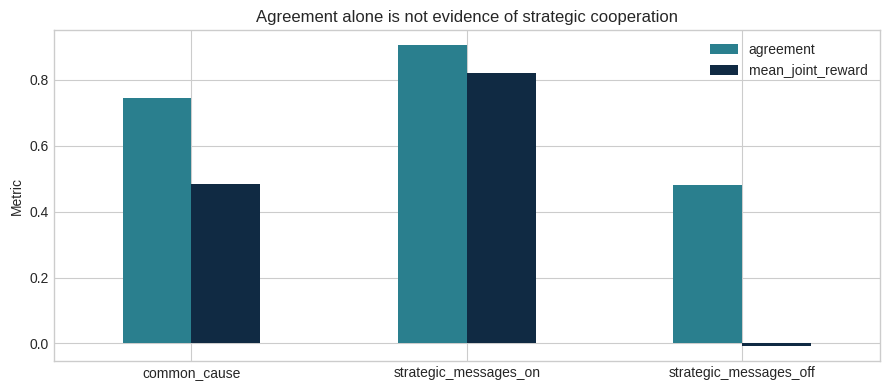

In [5]:
ax = summary[["agreement", "mean_joint_reward"]].plot(kind="bar", figsize=(9, 4), color=["#2A7F8E", "#102A43"])
ax.set_title("Agreement alone is not evidence of strategic cooperation")
ax.set_ylabel("Metric")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## Permutation test

We permute Agent A's action history. This preserves its marginal distribution while destroying temporal alignment. The test asks whether observed agreement exceeds what would arise from matched action frequencies alone.

The permutation test, implemented in the `permutation_pvalue` function and applied in this cell, is designed to determine if the observed agreement between Agent A and Agent B is statistically significant, or if it could simply arise by chance given their individual action frequencies. Here's a breakdown:

1.  **Purpose**: The core idea is to test a null hypothesis: that the observed correlation or agreement between agent actions is purely coincidental, resulting from their individual action biases rather than any meaningful interaction or shared cause. It assesses whether the observed agreement is *greater* than what you'd expect if Agent A's actions were completely shuffled relative to Agent B's.

2.  **`permutation_pvalue` Function**: This function takes a DataFrame of agent interactions and performs the following steps:
    *   **`observed = (df.a == df.b).mean()`**: It first calculates the actual proportion of times Agent A and Agent B took the same action (agreement) in the original, unshuffled data.
    *   **Null Distribution**: It then creates a 'null distribution' by repeatedly (2000 times, as `reps=2000`) shuffling Agent A's actions (`rng.permutation(df.a.to_numpy())`) while keeping Agent B's actions in their original order (`df.b.to_numpy()`). For each shuffle, it calculates the agreement between the permuted Agent A actions and Agent B's actions. This simulates what the agreement would look like if there were no actual relationship between their actions, only chance.
    *   **P-value Calculation**: The p-value is calculated as the proportion of times the agreement from the shuffled data was greater than or equal to the `observed` agreement. A small p-value (typically < 0.05) suggests that the observed agreement is unlikely to be due to chance under the null hypothesis, and thus provides evidence against the null hypothesis.

3.  **Results Interpretation**:
    *   **`common_cause`**: The `observed_agreement` is 0.745, significantly higher than the `null_mean` of approximately 0.5 (which is what you'd expect from random actions with ~50% share rate). The `p_value` is 0.0005, which is very low. This indicates that the high agreement in the common-cause scenario is statistically significant and not due to random chance; it's driven by the shared signal.
    *   **`strategic`**: Here, the `observed_agreement` is even higher at 0.905, again much greater than the `null_mean`. The `p_value` is also 0.0005. This strongly suggests that when communication is enabled in a strategic setting, the agents' actions are significantly aligned, demonstrating a clear causal effect of the strategic interaction with communication.
    *   **`strategic_no_messages`**: In this scenario, the `observed_agreement` is 0.4817, which is very close to the `null_mean` of approximately 0.5. Crucially, the `p_value` is 0.8466, which is very high. This means that the observed agreement in this condition is *not* statistically significant; it's well within the range of what could be expected if Agent A's actions were just randomly paired with Agent B's. This result is a key finding: it confirms that removing communication in the strategic setting effectively breaks the causal link between their actions, reducing their agreement to chance levels, and distinguishing strategic cooperation from mere correlation.

In [7]:
def permutation_pvalue(df, reps=2000):
    observed = (df.a == df.b).mean()
    null = np.empty(reps)
    for i in range(reps):
        null[i] = (rng.permutation(df.a.to_numpy()) == df.b.to_numpy()).mean()
    return observed, null, (1 + np.sum(null >= observed)) / (reps + 1)

tests = {}
for name, df in {"common_cause": baseline, "strategic": strategic, "strategic_no_messages": strategic_cut}.items():
    obs, null, p = permutation_pvalue(df)
    tests[name] = {"observed_agreement": obs, "null_mean": null.mean(), "p_value": p}
pd.DataFrame(tests).T.round(4)

,observed_agreement,null_mean,p_value
common_cause,0.7450,0.4995,0.0005
strategic,0.9050,0.5001,0.0005
strategic_no_messages,0.4817,0.5002,0.8386


## Strongest permissible conclusion

The communication intervention distinguishes the strategic mechanism from the common-cause mechanism in this environment. High correlation by itself does not. The result validates a diagnostic principle, not a claim about deployed AI agents.

## Evidentiary boundary

Interpret every numerical result as conditional on the stated rules, parameters, seed, and model class. A result may illustrate a mechanism or reject a null hypothesis inside this synthetic environment. It does not establish intention, consciousness, deception, alignment, or universal LLM behavior.

## Conclusion

This notebook has presented a controlled, synthetic experiment designed to illuminate the crucial distinction between mere correlation and genuine strategic cooperation in agent interactions. Through a series of carefully constructed simulations, we have demonstrated that while high agreement between agents can arise from various mechanisms—be it a common external cause or a strategic interaction with communication—only specific causal interventions can reliably disentangle these underlying dynamics. Our findings reinforce the central tenet that correlation, while often indicative, does not inherently imply causation, and thus, observed similarities in agent behavior are insufficient evidence for strategic cooperation without a rigorous experimental design.

The experimental design meticulously compared three scenarios: a 'common cause' baseline, a 'strategic' interaction with communication enabled, and a 'strategic' interaction with communication disabled. The summary statistics, including agreement rates, joint rewards, and inter-agent correlations, provided initial insights. Both the common-cause and strategic-with-communication scenarios exhibited high agreement and positive joint rewards, alongside significant correlations. This highlights the ambiguity of relying solely on observational metrics for inferring strategic depth. It was the negative control—the 'strategic' scenario with communication removed—that served as the pivotal intervention, drastically reducing agreement, joint reward, and correlation to chance levels. This stark contrast causally implicates communication as a critical enabler of the observed strategic cooperation.

The permutation test further substantiated these qualitative observations with statistical rigor. By demonstrating that the observed agreement in both the common-cause and strategic-with-communication scenarios significantly exceeded what could be expected by chance (extremely low p-values), we confirmed the statistical significance of their alignment. Conversely, the high p-value in the 'strategic-no-messages' scenario provided strong evidence that, without communication, the agents' actions were effectively uncorrelated, resembling random pairings rather than any meaningful interaction. This result directly supports our null hypothesis rejection for the strategic-with-communication case, while upholding it for the strategic-without-communication case.

In essence, this research validates a diagnostic principle: that causal interventions, particularly those manipulating information flow or communication channels, are indispensable for distinguishing true strategic interdependence from other forms of behavioral synchronization. It serves as a methodological blueprint for analyzing complex multi-agent systems, including advanced AI, where inferring intentions or strategic depth from observable actions alone is prone to error. The notebook deliberately operates within a synthetic, safe, and mechanism-oriented environment, emphasizing that its conclusions are conditional on the stated rules, parameters, and model class. It does not generalize to real-world incidents or make claims about the internal states of deployed AI agents, but rather provides a robust framework for understanding the evidentiary boundaries in attributing causality in cooperative behaviors.